****
IMPORT
****

In [15]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


****
FIRST OBSERVATION
****

Utilisation de ``Data Wrangler`` pour observer visuellement le contenu de chacue fichier csv. Permet de voir le nombre de colonne, ligne, Mix, Max, répartition des veleurs, valeurs manquantes.

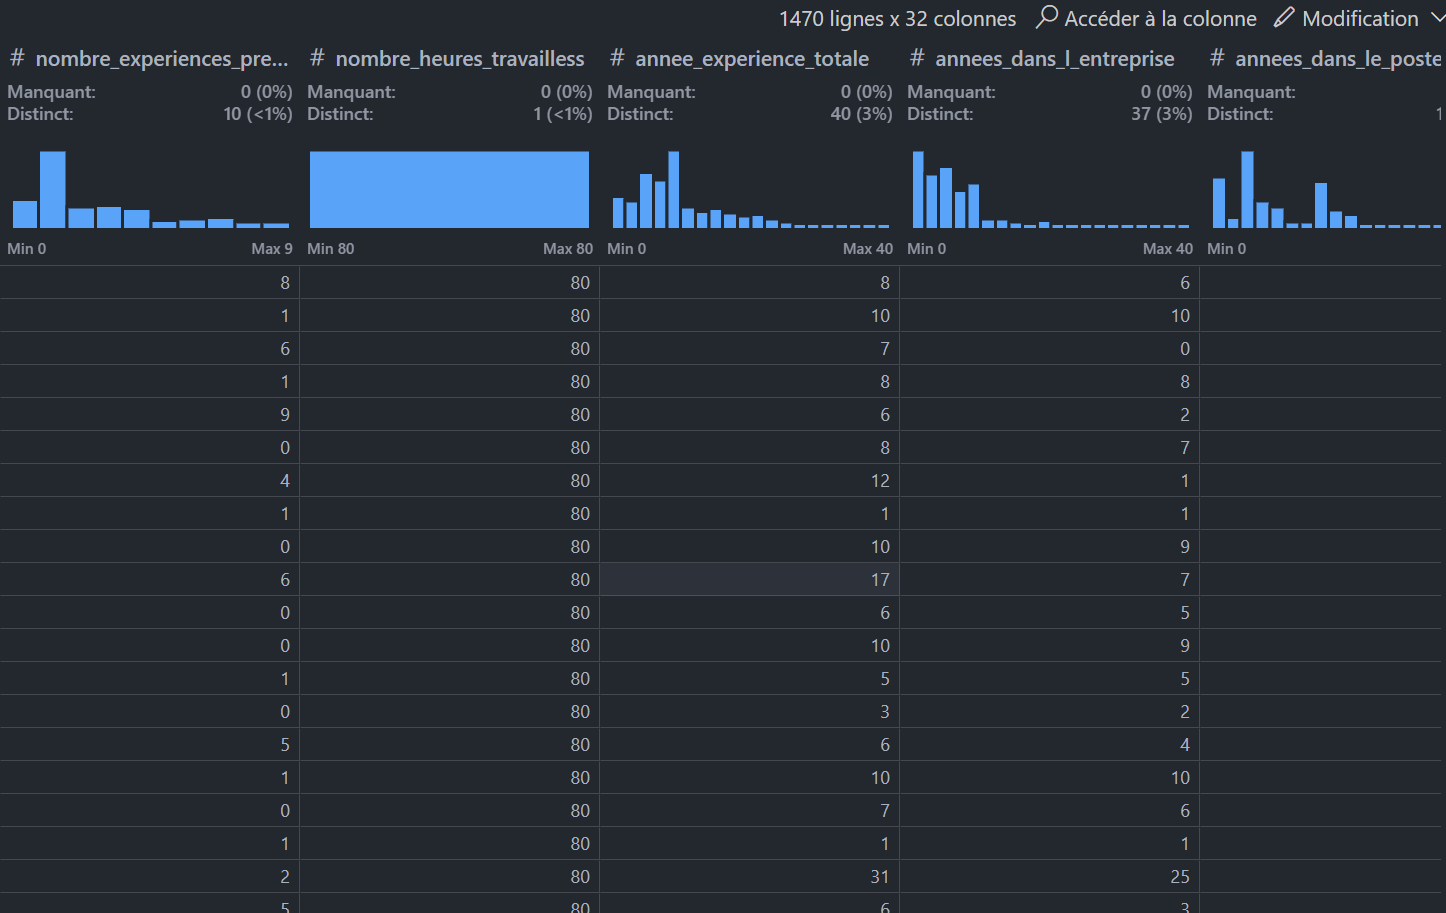

****
FUSION DATASET
****

In [ ]:
# 1. Chargement des fichiers
eval_df = pd.read_csv("../data/extrait_eval.csv")
sirh_df = pd.read_csv("../data/extrait_sirh.csv")
sondage_df = pd.read_csv("../data/extrait_sondage.csv")

# 2. Fonction de nettoyage pour extraire uniquement le chiffre des identifiants
def extract_numeric_id(val):
    if pd.isna(val):
        return None
    # Utilise une regex pour extraire tous les chiffres trouvés dans la chaîne
    numbers = re.findall(r'\d+', str(val))
    return int(numbers[0]) if numbers else None

# 3. Application du nettoyage sur les colonnes clés
# On s'assure que toutes les colonnes de jointure sont au format numérique
eval_df['id_user'] = eval_df['eval_number'].apply(extract_numeric_id)
sirh_df['id_user'] = sirh_df['id_employee'].apply(extract_numeric_id)
sondage_df['id_user'] = sondage_df['code_sondage'].apply(extract_numeric_id)

# 4. Fusion des datasets
# On utilise une fusion 'outer' pour ne perdre aucune donnée si un employé manque dans une source
# Tu peux passer en 'inner' si tu veux seulement les employés présents dans les 3 fichiers
merged_df = pd.merge(sirh_df, eval_df, on='id_user', how='outer')
merged_df = pd.merge(merged_df, sondage_df, on='id_user', how='outer')

# 5. Nettoyage final : suppression de la colonne clé temporaire et des doublons
merged_df = merged_df.drop(columns=['eval_number', 'id_employee', 'code_sondage'])

# 6. Sauvegarde en Parquet
output_path = "../data/merged_dataset.parquet"
merged_df.to_parquet(output_path, index=False)

print(f"✅ Fusion réussie ! Dataset final sauvegardé sous : {output_path}")
print(f"Dimensions du nouveau dataset : {merged_df.shape}")

In [ ]:
df = pd.read_parquet("../data/merged_dataset.parquet")

****
ALL FEATURE
****

In [ ]:
def analyser_structure(df, nom_fichier):
    """
    Analyse un dataframe déjà chargé.
    """
    print(f"\n--- Analyse de : {nom_fichier} ---")
    print(f"Nombre total de colonnes : {len(df.columns)}")
    print("\nListe des colonnes :")
    
    for i, col in enumerate(df.columns, 1):
        type_col = df[col].dtype
        print(f"{i:02d} | {col:<30} | Type : {type_col}")

# --- Exécution ---
if __name__ == "__main__":
    # 1. Chargement direct du fichier
    chemin = "../data/merged_dataset.parquet"
    df = pd.read_parquet(chemin)
    
    # 2. Appel de la fonction avec le dataframe chargé
    analyser_structure(df, "merged_dataset.parquet")


--- Analyse de : merged_hr_data.parquet ---
Nombre total de colonnes : 32

Liste des colonnes :
01 | age                            | Type : int64
02 | genre                          | Type : object
03 | revenu_mensuel                 | Type : int64
04 | statut_marital                 | Type : object
05 | departement                    | Type : object
06 | poste                          | Type : object
07 | nombre_experiences_precedentes | Type : int64
08 | nombre_heures_travailless      | Type : int64
09 | annee_experience_totale        | Type : int64
10 | annees_dans_l_entreprise       | Type : int64
11 | annees_dans_le_poste_actuel    | Type : int64
12 | id_user                        | Type : int64
13 | satisfaction_employee_environnement | Type : int64
14 | note_evaluation_precedente     | Type : int64
15 | niveau_hierarchique_poste      | Type : int64
16 | satisfaction_employee_nature_travail | Type : int64
17 | satisfaction_employee_equipe   | Type : int64
18 | satisfaction_emp

****
Répartition des valeur entre Partie & Rester
****

In [5]:
# 2. Nettoyage spécifique : augementation_salaire_precedente
# On retire le '%' et on convertit en numérique
df['augementation_salaire_precedente'] = (
    df['augementation_salaire_precedente']
    .astype(str)
    .str.replace('%', '', regex=False)
    .apply(pd.to_numeric, errors='coerce')
)

# 3. Préparation des colonnes
cols_a_exclure = [
    'nombre_heures_travailless', 
    'nombre_employee_sous_responsabilite', 
    'ayant_enfants',
    'id_user'
]
df_analyse = df.drop(columns=cols_a_exclure, errors='ignore')
target = 'a_quitte_l_entreprise'

# Identification des colonnes
colonnes_numeriques = df_analyse.select_dtypes(include=['number']).columns.tolist()
if target in colonnes_numeriques:
    colonnes_numeriques.remove(target)

colonnes_categoriel = df_analyse.select_dtypes(include=['object', 'category']).columns.tolist()
if target in colonnes_categoriel:
    colonnes_categoriel.remove(target)

# 4. Analyse Numérique (Moyennes)
print("--- Analyse Moyennes : Variables Numériques (incluant augmentation) ---")
stats_num = df_analyse.groupby(target)[colonnes_numeriques].mean().T
print(stats_num)

# 5. Analyse Catégorielle (Double Pourcentage)
# Total des "Oui" (ceux qui ont quitté) pour le calcul du 1er indicateur
total_oui = df_analyse[df_analyse[target] == 'Oui'].shape[0]

print("\n--- Analyse Répartition : Variables Catégorielles ---")
for col in colonnes_categoriel:
    # Tableau croisé des effectifs
    ct = pd.crosstab(df_analyse[col], df_analyse[target])
    
    # 1. % de Oui dans la catégorie par rapport au total des Oui
    # (Ex: Parmi tous les départs, quelle part sont des Célibataires ?)
    pct_dans_total_oui = (ct['Oui'] / total_oui) * 100
    
    # 2. % de Oui par rapport au total de la catégorie
    # (Ex: Parmi tous les Célibataires, quel % est parti ?)
    pct_par_categorie = (ct['Oui'] / ct.sum(axis=1)) * 100
    
    # Fusion pour affichage
    resultat = pd.DataFrame({
        '% dans total Oui': pct_dans_total_oui,
        '% de départ par Catégorie': pct_par_categorie
    }).round(2)
    
    print(f"\nRépartition pour : {col}")
    print(resultat)

--- Analyse Moyennes : Variables Numériques (incluant augmentation) ---
a_quitte_l_entreprise                              Non          Oui
age                                          37.561233    33.607595
revenu_mensuel                             6832.739659  4787.092827
nombre_experiences_precedentes                2.645580     2.940928
annee_experience_totale                      11.862936     8.244726
annees_dans_l_entreprise                      7.369019     5.130802
annees_dans_le_poste_actuel                   4.484185     2.902954
satisfaction_employee_environnement           2.771290     2.464135
note_evaluation_precedente                    2.770479     2.518987
niveau_hierarchique_poste                     2.145985     1.637131
satisfaction_employee_nature_travail          2.778589     2.468354
satisfaction_employee_equipe                  2.733982     2.599156
satisfaction_employee_equilibre_pro_perso     2.781022     2.658228
note_evaluation_actuelle                    

`OBSERVATION`

- On observe déjà des corrélations possibles comme le revenu qui est plus elevé chez les personnes resté. Celle qui sont resté sont présent dans l'entreprise depuis plus long temps avec plus d'experience. Pour autant on leurs évaluations semble semblable (hypothèse, les jeunes salarié ce trouve peut-être sous rémunéré par rapport à leurs plus ancien collaborateur, malgré une productivité similaire).
- On peux voir aussi une nette différence de localisation dans les logement par rapport à l'entreprise.
- Les personnes sans partnaire semble aussi plus affecté que les autres (plus facile de changer de localité et prendre des risques)
- Certain poste semble aussi plus affecté que d'autre.
- On peut aussi constater une certaine importante des heurs supplémentaires sur les départs.

****
Graphique
****

C:\Users\Nérion\AppData\Local\Temp\ipykernel_24760\3672370600.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='a_quitte_l_entreprise', y='revenu_mensuel', palette='Set2')


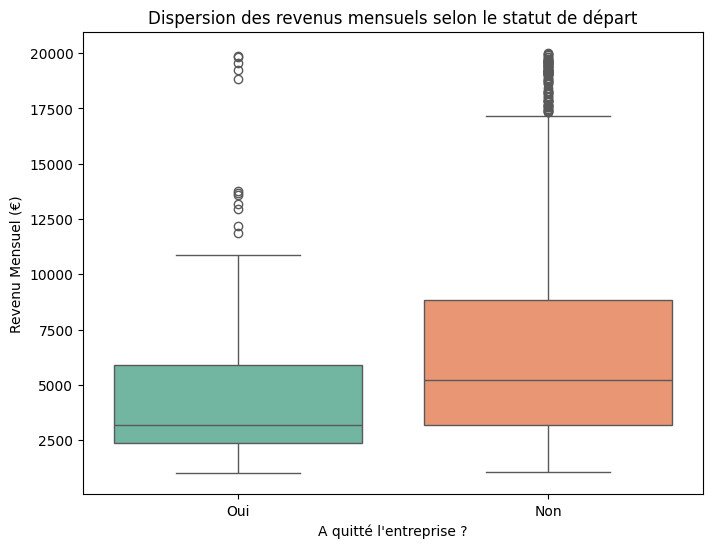

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='a_quitte_l_entreprise', y='revenu_mensuel', palette='Set2')
plt.title("Dispersion des revenus mensuels selon le statut de départ")
plt.xlabel("A quitté l'entreprise ?")
plt.ylabel("Revenu Mensuel (€)")
plt.show()

`OBSERVATION`

- On voit clairement un écart de revenu entre ceux qui quitte l'entreprise et ceux qui y sont rester, confirmant que cette feature doit avoir un impact important.

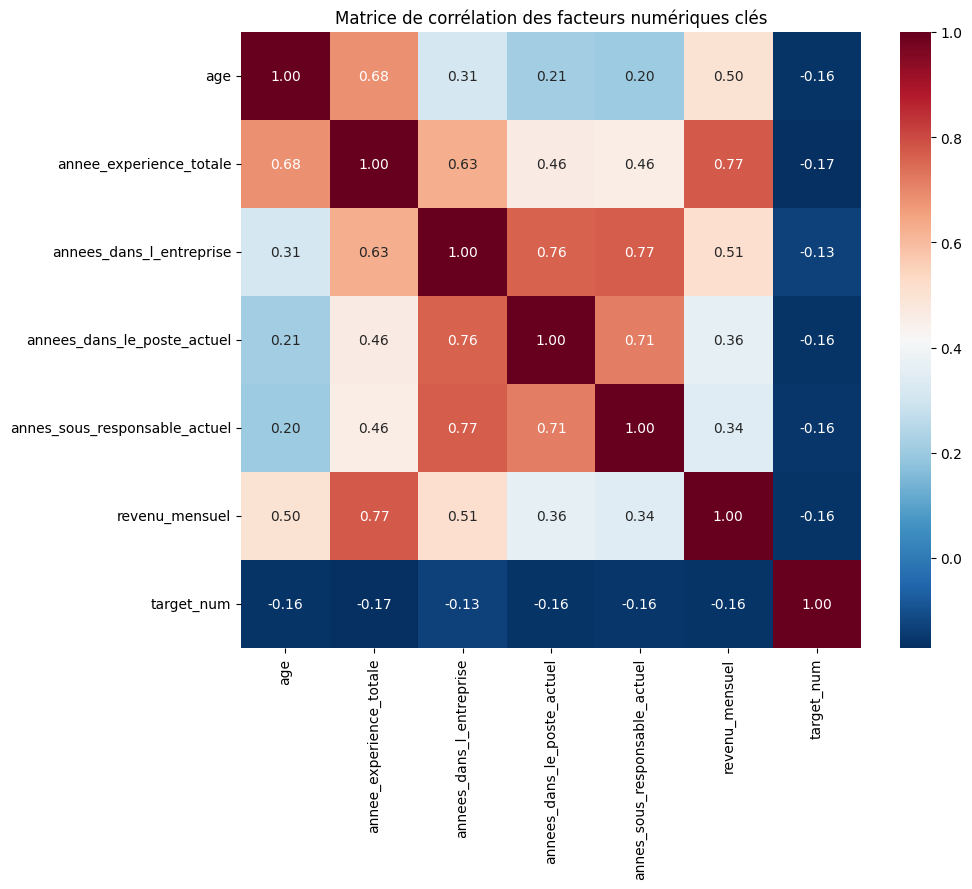

In [8]:
# Sélection des variables liées au temps et à la satisfaction
cols_temps = ['age', 'annee_experience_totale', 'annees_dans_l_entreprise', 
              'annees_dans_le_poste_actuel', 'annes_sous_responsable_actuel', 'revenu_mensuel']

# On encode rapidement la cible en numérique (0 ou 1) pour l'inclure dans la corrélation
df_temp = df.copy()
df_temp['target_num'] = df_temp['a_quitte_l_entreprise'].map({'Oui': 1, 'Non': 0})

plt.figure(figsize=(10, 8))
sns.heatmap(df_temp[cols_temps + ['target_num']].corr(), annot=True, cmap='RdBu_r', fmt=".2f")
plt.title("Matrice de corrélation des facteurs numériques clés")
plt.show()

`OBSERVATION`

- Comme le montre cette matrice certaine feature risque d'être redondant comme les annees_dans_l_entreprise, anne_dans_le_poste_actuel, annes_sous_responsable_actuel et année d'expercience_total. Il sera donc inutile de tout les avoirs dans le dataset pour l'entrainement du modèle.

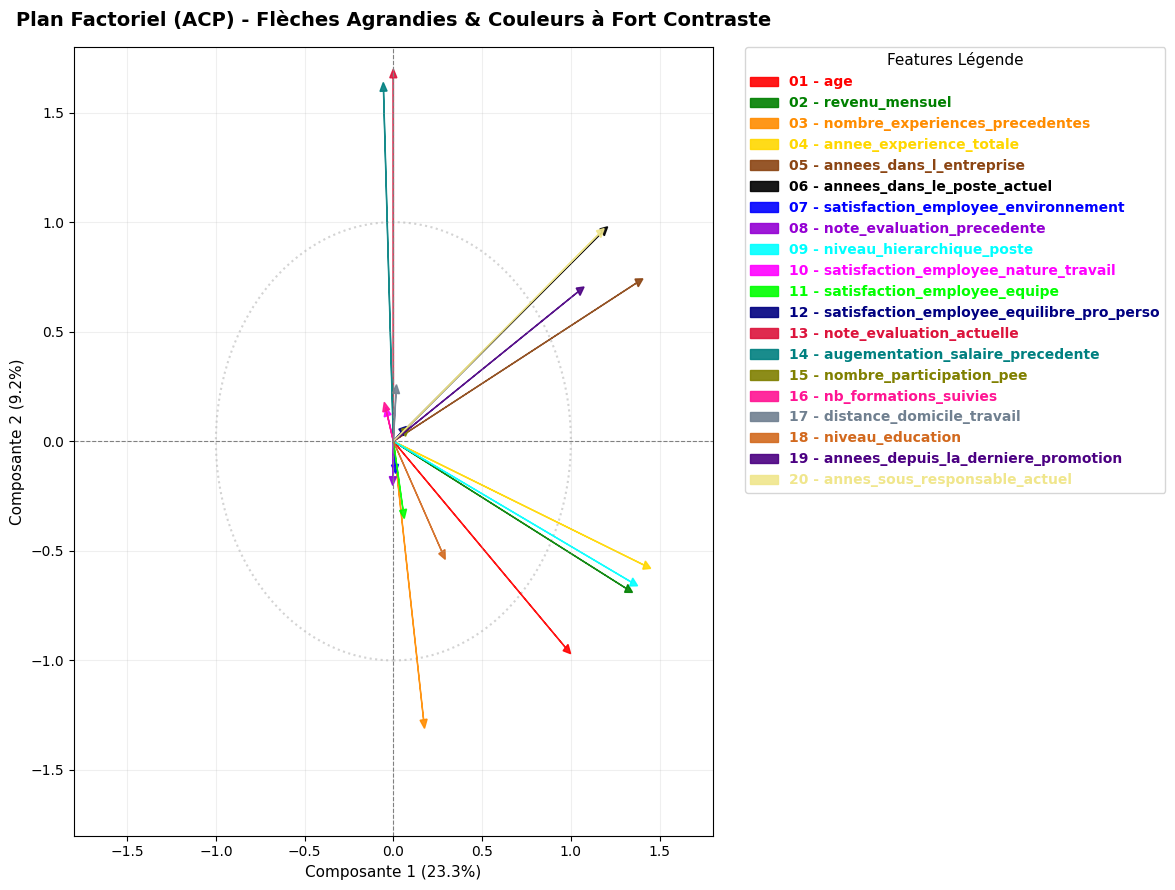

In [35]:
# 1. Chargement et nettoyage
df = pd.read_parquet("../data/merged_hr_data.parquet")
df['augementation_salaire_precedente'] = (
    df['augementation_salaire_precedente']
    .astype(str)
    .str.replace('%', '', regex=False)
    .apply(pd.to_numeric, errors='coerce')
)
cols_a_exclure = ['nombre_heures_travailless', 'nombre_employee_sous_responsabilite', 'ayant_enfants', 'id_user']
df_analyse = df.drop(columns=cols_a_exclure, errors='ignore')

# 2. Traitement ACP
colonnes_numeriques = df_analyse.select_dtypes(include=['number']).columns.tolist()
if 'a_quitte_l_entreprise' in colonnes_numeriques:
    colonnes_numeriques.remove('a_quitte_l_entreprise')
df_num = df_analyse[colonnes_numeriques].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

pca = PCA(n_components=2)
pca.fit(X_scaled)
composantes = pca.components_

# --- CONFIGURATION DU VÉRITABLE ÉTIREMENT ---
fig, ax = plt.subplots(figsize=(12, 9))

# Coefficient pour allonger artificiellement toutes les flèches
allongement_fleches = 3.5 

# SELECTION DE COULEURS ULTRA-CONTRASTÉES ET FRANCHES
# Liste personnalisée de noms de couleurs web (fortement différenciées)
liste_couleurs_distinctes = [
    'red', 'green', 'darkorange', 'gold', 'saddlebrown', 
    'black', 'blue', 'darkviolet', 'cyan', 'magenta', 
    'lime', 'navy', 'crimson', 'teal', 'olive', 
    'deeppink', 'slategrey', 'chocolate', 'indigo', 'khaki'
]

# Dessin de la croix centrale (+)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Dessin du cercle théorique de base (rayon = 1, sans modification)
cercle_theorique = plt.Circle((0,0), 1.0, color='lightgray', fill=False, linestyle=':', linewidth=1.5)
ax.add_artist(cercle_theorique)

# Tracé des flèches étirées
for i, col in enumerate(colonnes_numeriques):
    x = composantes[0, i] * allongement_fleches
    y = composantes[1, i] * allongement_fleches
    
    # Utilisation de l'opérateur modulo (%) au cas où il y ait plus de colonnes que de couleurs
    col_color = liste_couleurs_distinctes[i % len(liste_couleurs_distinctes)]
    
    ax.arrow(0, 0, x, y, head_width=0.04, head_length=0.04, 
             color=col_color, alpha=0.9, label=f"{i+1:02d} - {col}")

# CADRAGE FIXE : On fige l'échelle totale de la fenêtre pour voir l'effet de zoom
limite_affichage = 1.8  
plt.xlim(-limite_affichage, limite_affichage)
plt.ylim(-limite_affichage, limite_affichage)

plt.title("Plan Factoriel (ACP) - Flèches Agrandies & Couleurs à Fort Contraste", fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f"Composante 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
plt.ylabel(f"Composante 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
plt.grid(True, alpha=0.2)

# Légende externe colorée sur le côté
leg = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., 
                 fontsize=10, title="Features Légende", title_fontsize=11)

for i, text in enumerate(leg.get_texts()):
    col_color = liste_couleurs_distinctes[i % len(liste_couleurs_distinctes)]
    text.set_color(col_color)
    text.set_weight('bold') # Met le texte en gras pour accentuer la lisibilité de la couleur

plt.tight_layout()
plt.show()

`OBSERVATION`

- Ici on peux apercevoir une forte corrélation entre revenu et le niveau hirearchique, ainsi qu'un peu moins avec l'expérience total.
- On retrouve les même corrélation que précédement.
- On constate aussi que l'augmentation du salaire semble avec une corélation avec note d'evaltion actuelle.
- On obeserve aussi avec la longueur des flèches quel feature aura plus d'impact que les autres. Certaine pourrais paraitre surprenante comme la satisfaction employee, mais comme vu plus haut cette feature etait quasi semblable à celle des personnes restés.

****
FEATURE ENGINEERING
****

In [46]:
# On repart de ton dataframe d'analyse
df_enriched = df.copy()

# 1. Encodage rapide des heures sup pour les calculs mathématiques (Oui=1, Non=0)
df_enriched['heures_sup_num'] = df_enriched['heure_supplementaires'].map({'Oui': 1, 'Non': 0}).fillna(0)

# 2. Création de tes ratios (avec sécurité contre la division par zéro)
df_enriched['revenu_par_experience_passee'] = df['revenu_mensuel'] / (df['nombre_experiences_precedentes'] + 1)
densite_xp = (df_enriched['annee_experience_totale'] + 1) / df_enriched['age']
df_enriched['revenu_par_densite_experience'] = df_enriched['revenu_mensuel'] * densite_xp
df_enriched['performance_vs_revenu'] = df_enriched['note_evaluation_actuelle'] / df_enriched['revenu_mensuel']

# 3. Création des features RH avancées
# Évolution de la note (Performance en baisse ?)
df_enriched['evolution_evaluation'] = df_enriched['note_evaluation_actuelle'] - df_enriched['note_evaluation_precedente']

# Stagnation management
df_enriched['ratio_stagnation_responsable'] = df_enriched['annes_sous_responsable_actuel'] / (df_enriched['annees_dans_l_entreprise'] + 1)

# Facteur Épuisement (Distance boostée par les heures sup)
df_enriched['facteur_epuisement'] = df_enriched['distance_domicile_travail'] * (1 + df_enriched['heures_sup_num'])

print("✅ Nouvelles features créées avec succès !")
print(f"Nouveau nombre de colonnes : {len(df_enriched.columns)}")

✅ Nouvelles features créées avec succès !
Nouveau nombre de colonnes : 39


`OBSERVATION`

- revenu_par_experience_passee => Mesurer le coût d'opportunité de la fidélité. Un employé ayant cumulé beaucoup d'expériences passées mais qui touche un petit salaire actuel reflète un profil instable et frustré par son niveau de vie, augmentant drastiquement sa volatilité.

- revenu_par_densite_experience => Mesurer la justesse de la rémunération face à la maturité de la carrière. Un employé senior ou très expérimenté par rapport à son âge, mais dont le salaire ne reflète pas cette densité professionnelle, développera un fort sentiment de dévalorisation qui le poussera au départ.

- performance_vs_revenu => Mesurer l'augmentation du salaire selon la performance. Un employé qui performe mais sous-payés risque d'avantage d'aller voir la ailleurs.

- evolution_evaluation => Mesurer la présence d'une évolution ou regression. Un score qui diminu est le premier symptôme mesurable d'un employé qui "décroche" ou d'un conflit managérial sous-jacent.

- ratio_stagnation_responsable => Mesurer le temps passer sous le même responssable. Passer une trop grande partie de sa carrière dans l'entreprise sous les ordres du même manager peut indiquer un manque d'évolution professionnelle (stagnation) ou une dépendance relationnelle qui, si elle se passe mal, mène tout droit à la démission.

- facteur_epuisement => Mesurer l'indice d'usure physique accumulée. Cumuler une grande distance domicile-travail avec la réalisation fréquente d'heures supplémentaires engendre une fatigue critique, agissant comme le déclencheur principal d'un burnout ou d'une rupture conventionnelle.

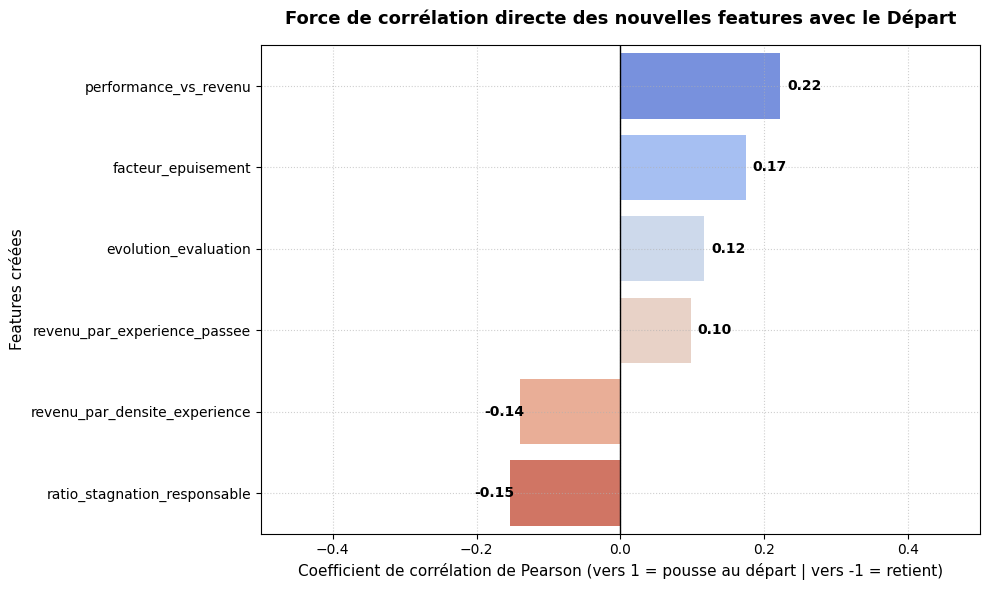

In [43]:
# 1. On applique le code précédent pour générer le dataframe enrichi
df_enriched = df.copy()

# Encodage numérique obligatoire de la cible et des heures sup
df_enriched['target_num'] = df_enriched['a_quitte_l_entreprise'].map({'Oui': 1, 'Non': 0})
df_enriched['heures_sup_num'] = df_enriched['heure_supplementaires'].map({'Oui': 1, 'Non': 0}).fillna(0)

# Nettoyage de l'augmentation de salaire
df_enriched['augementation_salaire_precedente'] = (
    df_enriched['augementation_salaire_precedente']
    .astype(str)
    .str.replace('%', '', regex=False)
    .apply(pd.to_numeric, errors='coerce')
)

# Création de tes features d'ingénierie
df_enriched['revenu_par_experience_passee'] = df_enriched['revenu_mensuel'] / (df_enriched['annee_experience_totale'] + 1)
df_enriched['revenu_par_densite_experience'] = df_enriched['revenu_mensuel'] / df_enriched['age']
df_enriched['performance_vs_revenu'] = df_enriched['note_evaluation_actuelle'] / df_enriched['revenu_mensuel']
df_enriched['evolution_evaluation'] = df_enriched['note_evaluation_actuelle'] - df_enriched['note_evaluation_precedente']
df_enriched['ratio_stagnation_responsable'] = df_enriched['annes_sous_responsable_actuel'] / (df_enriched['annees_dans_l_entreprise'] + 1)
df_enriched['facteur_epuisement'] = df_enriched['distance_domicile_travail'] * (1 + df_enriched['heures_sup_num'])

# 2. Liste des nouvelles features uniquement
nouvelles_features = [
    'revenu_par_experience_passee', 
    'revenu_par_densite_experience', 
    'performance_vs_revenu', 
    'evolution_evaluation', 
    'ratio_stagnation_responsable', 
    'facteur_epuisement'
]

# 3. Calcul de la corrélation avec la cible (target_num)
# On extrait la ligne correspondant à notre cible et on trie par force de corrélation
correlations = df_enriched[nouvelles_features + ['target_num']].corr()['target_num'].drop('target_num')
correlations_triees = correlations.sort_values(ascending=False).reset_index()
correlations_triees.columns = ['Feature', 'Correlation_Coefficient']

# 4. Tracé du graphique de corrélation directe
plt.figure(figsize=(10, 6))

# Palette coolwarm pour colorer en rouge les corrélations positives (facteurs de risque)
# et en bleu les corrélations négatives (facteurs de rétention)
sns.barplot(
    data=correlations_triees, 
    x='Correlation_Coefficient', 
    y='Feature', 
    palette='coolwarm',
    hue='Feature',
    legend=False
)

# Ajout d'une ligne verticale noire au centre (zéro corrélation)
plt.axvline(0, color='black', linestyle='-', linewidth=1)

# Habillage esthétique
plt.xlim(-0.5, 0.5) # Ajuste les limites selon tes coefficients réels
plt.title("Force de corrélation directe des nouvelles features avec le Départ", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Coefficient de corrélation de Pearson (vers 1 = pousse au départ | vers -1 = retient)", fontsize=11)
plt.ylabel("Features créées", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Affichage des valeurs exactes au bout de chaque barre
for index, row in correlations_triees.iterrows():
    val = row['Correlation_Coefficient']
    placement = val + 0.01 if val >= 0 else val - 0.05
    plt.text(placement, index, f"{val:.2f}", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

`Observation:`
- Les 4 première feature ont une corrélation avec les départs, tandis que les 2 denières sembles plutôt être corrélé avec le fait de retenir les employer. La plus pertinente semble être la feature performance_vs_revenu, ce qui apparait cohérent, un employé sous payé par rapport à s productivité sera plus susceptible d'aller voir ailleur.

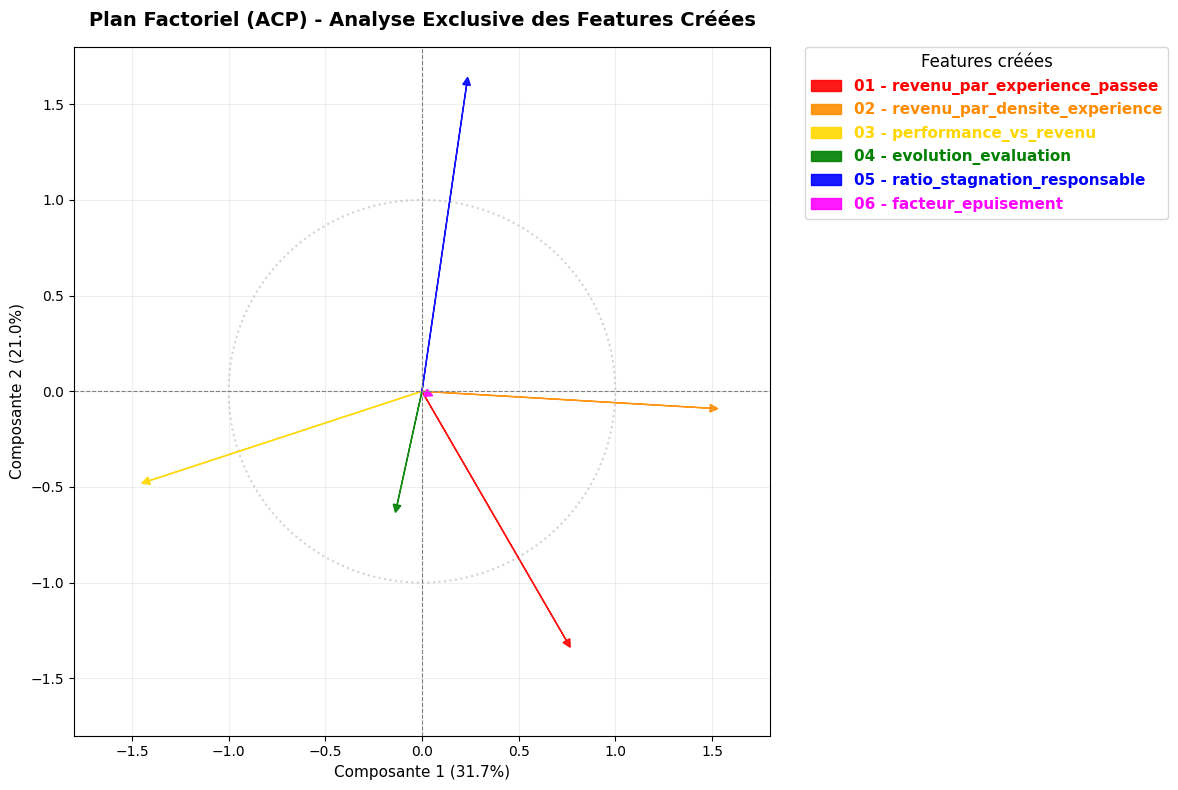

In [44]:
# 1. Chargement et Nettoyage de base
df = pd.read_parquet("../data/merged_hr_data.parquet")
df['heures_sup_num'] = df['heure_supplementaires'].map({'Oui': 1, 'Non': 0}).fillna(0)

# 2. CREATION EXCLUSIVE DE TES FEATURES
df_engineered = pd.DataFrame(index=df.index)

df_engineered['revenu_par_experience_passee'] = df['revenu_mensuel'] / (df['annee_experience_totale'] + 1)
df_engineered['revenu_par_densite_experience'] = df['revenu_mensuel'] / df['age']
df_engineered['performance_vs_revenu'] = df['note_evaluation_actuelle'] / df['revenu_mensuel']
df_engineered['evolution_evaluation'] = df['note_evaluation_actuelle'] - df['note_evaluation_precedente']
df_engineered['ratio_stagnation_responsable'] = df['annes_sous_responsable_actuel'] / (df['annees_dans_l_entreprise'] + 1)
df_engineered['facteur_epuisement'] = df['distance_domicile_travail'] * (1 + df['heures_sup_num'])

# Suppression des lignes contenant des NaN pour l'ACP
df_num_engineered = df_engineered.dropna()
colonnes_engineered = df_num_engineered.columns.tolist()

# 3. Traitement ACP
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num_engineered)

pca = PCA(n_components=2)
pca.fit(X_scaled)
composantes = pca.components_

# --- CONFIGURATION DU GRAPHIQUE ÉPURÉ ---
fig, ax = plt.subplots(figsize=(12, 8))

# Coefficient d'allongement pour étirer les flèches vers les bords
allongement_fleches = 2.2 

# Palette manuelle de couleurs unies et franches pour tes 6 features
liste_couleurs_distinctes = [
    'red',         # revenu_par_an_experience
    'darkorange',  # revenu_par_an_age
    'gold',        # performance_vs_revenu
    'green',       # evolution_evaluation
    'blue',        # ratio_stagnation_responsable
    'magenta'      # facteur_epuisement
]

# Dessin de la croix centrale (+)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Dessin du cercle théorique de base (rayon = 1.0)
cercle_theorique = plt.Circle((0,0), 1.0, color='lightgray', fill=False, linestyle=':', linewidth=1.5)
ax.add_artist(cercle_theorique)

# Tracé des flèches d'ingénierie
for i, col in enumerate(colonnes_engineered):
    x = composantes[0, i] * allongement_fleches
    y = composantes[1, i] * allongement_fleches
    col_color = liste_couleurs_distinctes[i]
    
    ax.arrow(0, 0, x, y, head_width=0.04, head_length=0.04, 
             color=col_color, alpha=0.9, label=f"{i+1:02d} - {col}")

# Cadrage fixe autour de l'affichage étiré
limite_affichage = 1.8  
plt.xlim(-limite_affichage, limite_affichage)
plt.ylim(-limite_affichage, limite_affichage)

plt.title("Plan Factoriel (ACP) - Analyse Exclusive des Features Créées", fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f"Composante 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=11)
plt.ylabel(f"Composante 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=11)
plt.grid(True, alpha=0.2)

# Légende externe colorée et en gras sur le côté droit
leg = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., 
                 fontsize=11, title="Features créées", title_fontsize=12)

for i, text in enumerate(leg.get_texts()):
    text.set_color(liste_couleurs_distinctes[i])
    text.set_weight('bold')

plt.tight_layout()
plt.show()

`Observation:`
- Chaque feature pointe dans une direction différente, ce qui nous indique qu'elle n'ont pas la même corrélation entre elle, ce qui est plutôt intéressant car elle apporterons donc chacune des informations indépendantes et complémentaires sur les raison de départ.

****
CREATION DATASET TRAINING
****

In [ ]:
# 1. Sélection de TOUTES les features numériques (brutes et créées)
features_numeriques = [
    'id_user',
    'revenu_par_densite_experience',
    'revenu_par_experience_passee',
    'performance_vs_revenu',
    'evolution_evaluation',
    'ratio_stagnation_responsable',
    'facteur_epuisement',
    'annees_depuis_la_derniere_promotion',
    'nombre_participation_pee',
    'niveau_hierarchique_poste',
    'age'
]

# On isole ces colonnes
df_final = df_enriched[features_numeriques].copy()

# Encodage de la cible en 0/1
df_final['a_quitte_l_entreprise'] = df_enriched['a_quitte_l_entreprise'].map({'Oui': 1, 'Non': 0})

# 2. ENCODAGE ORDINAL (Label Encoding) pour 'poste' et 'statut_marital'
# On transforme le texte en catégorie, puis on récupère le code numérique unique (.cat.codes)
df_final['poste_encoded'] = df_enriched['poste'].astype('category').cat.codes
df_final['statut_marital_encoded'] = df_enriched['statut_marital'].astype('category').cat.codes

# 3. Sécurité : suppression des éventuels NaN résiduels
df_final = df_final.dropna()

# 4. Sauvegarde dans le fichier Parquet
output_path = "../data/dataframe_training.parquet"
df_final.to_parquet(output_path, index=False)

print(f"✅ Fichier Parquet créé avec Label Encoding !")
print(f"Dimensions : {df_final.shape[0]} lignes et {df_final.shape[1]} colonnes.")

✅ Fichier Parquet créé avec Label Encoding !
Dimensions : 1470 lignes et 14 colonnes.
   poste_encoded  statut_marital_encoded
0              1                       0
1              0                       2
2              2                       0
3              0                       2
4              2                       2
